In [12]:
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
url = "https://stooq.com/q/d/l/?s=xagusd"
df = pd.read_csv(url, parse_dates=["Date"], index_col="Date")

In [14]:
print(df.head())

            Open  High   Low  Close
Date                               
1792-03-01  1.29  1.29  1.29   1.29
1792-06-01  1.29  1.29  1.29   1.29
1792-09-01  1.29  1.29  1.29   1.29
1792-12-01  1.29  1.29  1.29   1.29
1793-03-01  1.29  1.29  1.29   1.29


In [15]:
df.tail()

,Open,High,Low,Close
Date,,,,
2026-02-02,80.6540,87.942,71.4790,79.271
2026-02-03,80.1955,89.102,80.1090,85.321
2026-02-04,85.6405,92.190,83.3125,88.204
2026-02-05,88.4000,90.380,70.7390,70.958
2026-02-06,70.3930,71.152,64.1370,65.677


In [16]:
df_2000_on= df.loc["2000-01-01":"2026-02-04"]
df_2000_on.head()

,Open,High,Low,Close
Date,,,,
2000-01-03,5.42,5.42,5.36,5.36
2000-01-04,5.35,5.37,5.28,5.33
2000-01-05,5.32,5.32,5.14,5.19
2000-01-06,5.17,5.30,5.12,5.14
2000-01-07,5.14,5.19,5.13,5.17


In [17]:
price = df_2000_on["Close"].rename("silver")

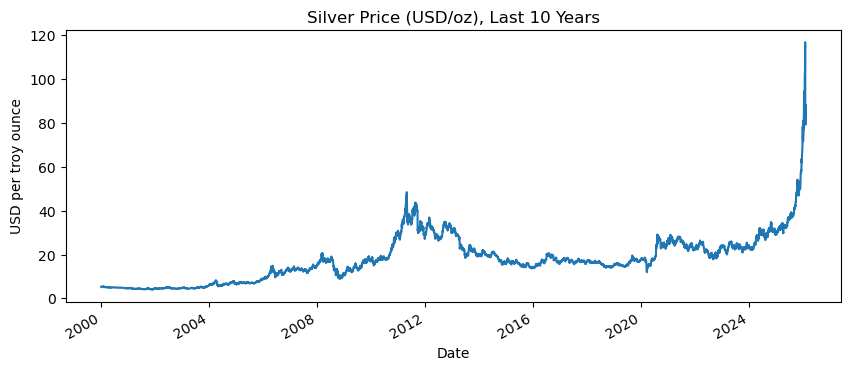

In [18]:

price.plot(figsize=(10,4), title="Silver Price (USD/oz), Last 10 Years")
plt.ylabel("USD per troy ounce")
plt.show()


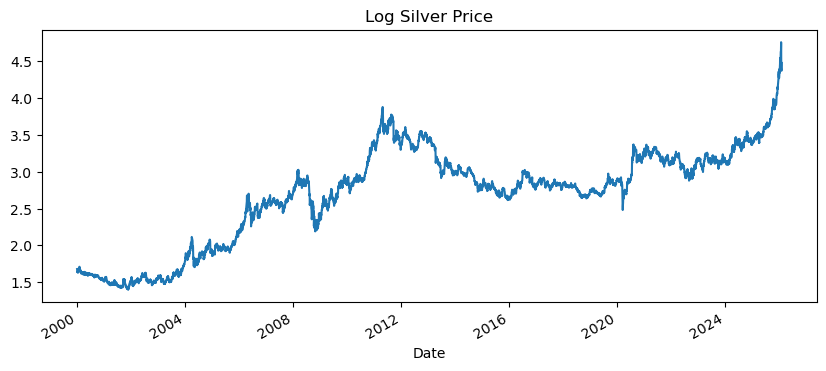

In [19]:
import numpy as np

log_price = np.log(price)
log_price.plot(figsize=(10,4), title="Log Silver Price")
plt.show()

In [20]:
returns = np.log(price).diff().dropna()

mean_daily = returns.mean()
std_daily = returns.std()

mean_daily, std_daily

(np.float64(0.0004205869257209206), 0.01951818967117267)

In [ ]:
window_size = 12
df_2000_on['Moving_Avg_12'] = df_2000_on['Close'].rolling(window=window_size).mean()
df_2000_on

In [28]:
df_2000_on.to_csv('silver2.csv')

/var/folders/zy/x4gc34qd36q0s944s4dk2n640000gn/T/ipykernel_8969/1463269646.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2000_on['Moving_Avg_12'] = df_2000_on['Close'].rolling(window=window_size).mean()


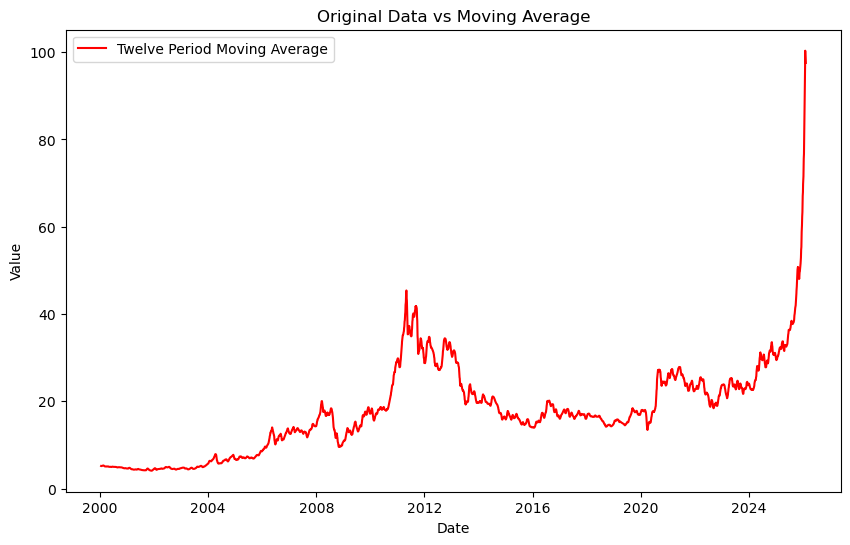

In [26]:
plt.figure(figsize=(10, 6))
#plt.plot(df.index, df_2000_on['Close'], label='Original Data')
plt.plot(df_2000_on.index, df_2000_on['Moving_Avg_12'], color='red', label='Twelve Period Moving Average')
plt.title('Original Data vs Moving Average')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()